# DS605 — Lab Assignment 4: End-to-End Machine Learning Project
## Airbnb Price Prediction (NYC 2019)

**Dataset:** Kaggle *New York City Airbnb Open Data* (`AB_NYC_2019.csv`)



In [1]:
import os
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / 'data' / 'AB_NYC_2019.csv').exists():
    ROOT = Path('..').resolve()
os.chdir(ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, TargetEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
import joblib

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)


---
## Task 1 — Data Analysis and Preparation

In [2]:
df = pd.read_csv('data/AB_NYC_2019.csv')
print("Shape:", df.shape)
df.head(3)

Shape: (48895, 16)


In [3]:
df.isnull().sum()

id                                     0
name                                  16
host_id                                0
host_name                             21
neighbourhood_group                    0
neighbourhood                          0
latitude                               0
longitude                              0
room_type                              0
price                                   0
minimum_nights                         0
number_of_reviews                      0
last_review                        10052
reviews_per_month                  10052
calculated_host_listings_count         0
availability_365                       0
dtype: int64

**Observations:**
- `last_review` and `reviews_per_month` are missing together for ~20.6% of rows — these are simply listings that have **never been reviewed**, not random missingness. We'll fill `reviews_per_month` with 0 and create a `never_reviewed` flag instead of dropping `last_review`'s information entirely.
- `name` and `host_name` have a handful of missing values (free-text/ID fields, not useful for price modeling) — dropped.
- No duplicate rows.


In [4]:
df['price'].describe()

count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64

`price` is heavily right-skewed (max \$10,000 vs median \$106), and there are **11 listings with price = \$0**, which are invalid/placeholder entries. We cap extreme outliers at the 99th percentile (~\$799) rather than deleting the whole right tail, and drop the \$0 rows.

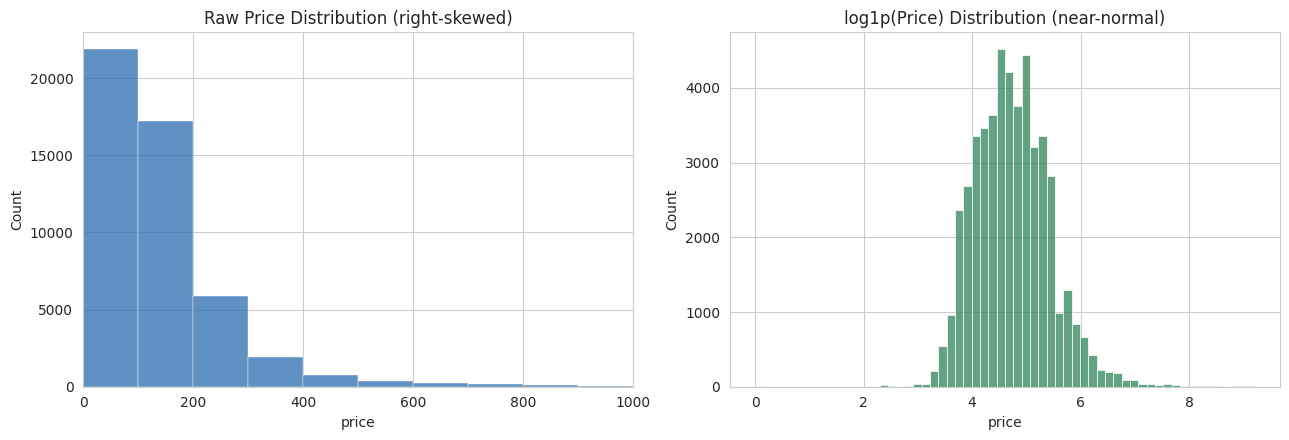

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df['price'], bins=100, ax=axes[0], color='#2b6cb0'); axes[0].set_xlim(0,1000)
axes[0].set_title('Raw Price Distribution (right-skewed)')
sns.histplot(np.log1p(df['price']), bins=60, ax=axes[1], color='#2f855a')
axes[1].set_title('log1p(Price) Distribution (near-normal)')
plt.tight_layout(); plt.show()

The log-transform produces a near-normal distribution, so we **train models on `log1p(price)`** and invert with `expm1` for dollar-scale metrics/predictions.

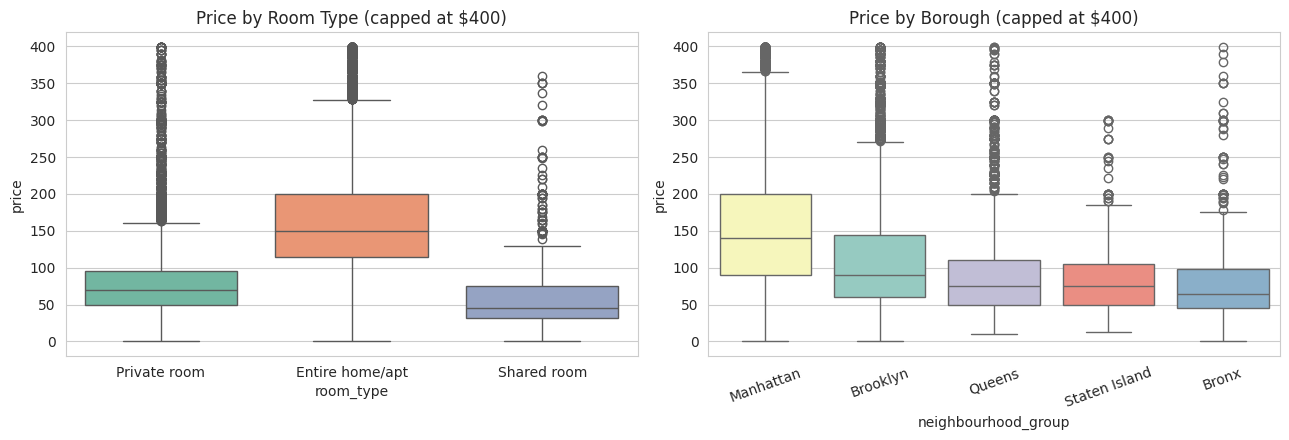

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(data=df[df['price']<400], x='room_type', y='price', ax=axes[0], hue='room_type', palette='Set2', legend=False)
axes[0].set_title('Price by Room Type (capped at $400)')
order = df.groupby('neighbourhood_group')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=df[df['price']<400], x='neighbourhood_group', y='price', order=order, ax=axes[1], hue='neighbourhood_group', palette='Set3', legend=False)
axes[1].set_title('Price by Borough (capped at $400)'); axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

`room_type` and borough (`neighbourhood_group`) are clearly the strongest visible price drivers: **Entire home/apt** and **Manhattan** command the highest prices.

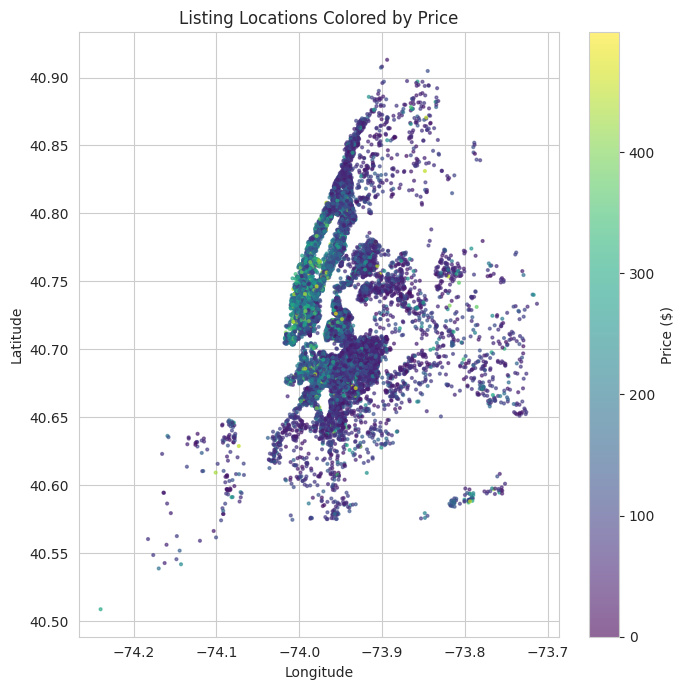

In [7]:
fig, ax = plt.subplots(figsize=(7,7))
sample = df[df['price']<500].sample(15000, random_state=42)
sc = ax.scatter(sample['longitude'], sample['latitude'], c=sample['price'], cmap='viridis', s=4, alpha=0.6)
plt.colorbar(sc, label='Price ($)')
ax.set_title('Listing Locations Colored by Price'); ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.tight_layout(); plt.show()

Prices form a clear **geographic gradient** centered on Manhattan, motivating a `dist_from_center` engineered feature.

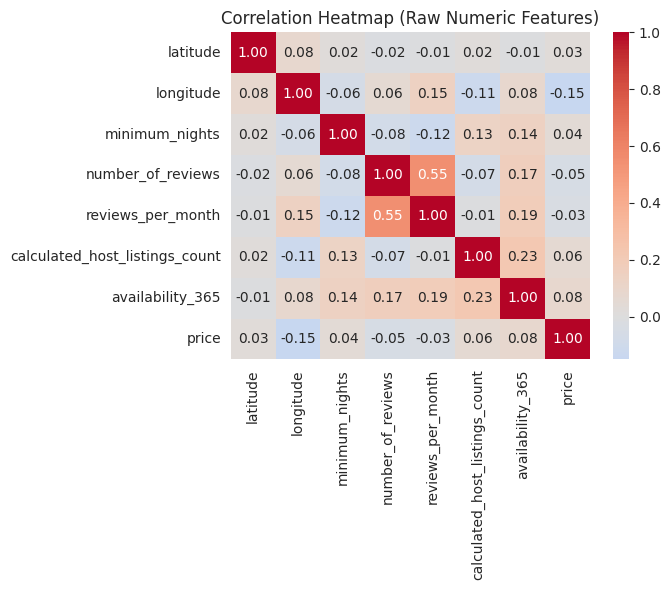

In [8]:
num_cols = ['latitude','longitude','minimum_nights','number_of_reviews','reviews_per_month',
            'calculated_host_listings_count','availability_365','price']
fig, ax = plt.subplots(figsize=(7,6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Heatmap (Raw Numeric Features)')
plt.tight_layout(); plt.show()

Linear correlations with raw `price` are weak (all |r| < 0.16) — this confirms price is driven mainly by **categorical** factors (room type, location) and **non-linear** relationships, which motivates using tree-based models over plain linear regression.

### Cleaning & Feature Engineering


In [9]:
df = df[df['price'] > 0].copy()
price_cap = df['price'].quantile(0.99)
min_nights_cap = df['minimum_nights'].quantile(0.99)
df = df[df['price'] <= price_cap].copy()
df['minimum_nights'] = df['minimum_nights'].clip(upper=min_nights_cap)

# Missing values
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)
df['never_reviewed'] = df['last_review'].isna().astype(int)
df = df.drop(columns=['last_review', 'name', 'host_name', 'id', 'host_id'])

# Feature engineering
manhattan_center = (40.7580, -73.9855)
df['dist_from_center'] = np.sqrt((df['latitude']-manhattan_center[0])**2 + (df['longitude']-manhattan_center[1])**2)
df['has_reviews'] = (df['number_of_reviews'] > 0).astype(int)
df['availability_ratio'] = df['availability_365'] / 365.0
df['is_multi_listing_host'] = (df['calculated_host_listings_count'] > 1).astype(int)
for col in ['minimum_nights','number_of_reviews','reviews_per_month','calculated_host_listings_count']:
    df[f'log_{col}'] = np.log1p(df[col])
df['log_price'] = np.log1p(df['price'])

print("Final shape:", df.shape, "| nulls:", df.isnull().sum().sum())

Final shape: (48410, 21) | nulls: 0

**Preprocessing decisions summary:**
| Decision | Rationale |
|---|---|
| Drop price ≤ 0 (11 rows) | Invalid listings, not real prices |
| Cap price at 99th pct (~\$799) and `minimum_nights` at 99th pct (~45) | Reduce influence of extreme outliers without discarding the whole tail |
| Fill `reviews_per_month` NaN → 0, add `never_reviewed` flag | Missingness is meaningful ("never reviewed"), not random |
| Drop `name`, `host_name`, `id`, `host_id` | Free text / identifiers, not predictive |
| Log-transform `price` (target) and skewed count features | Right-skewed distributions hurt linear models & stabilize variance |
| Engineer `dist_from_center`, `availability_ratio`, `has_reviews`, `is_multi_listing_host` | Capture non-linear, domain-informed signal (centrality, host scale, activity) |
| High-cardinality `neighbourhood` (221 values) → `TargetEncoder` (in-pipeline, cross-fitted) instead of one-hot | Avoids a 221-column sparse explosion while avoiding target leakage |


---
## Task 2 — Model Training, Tuning, and Evaluation

**Feature set:** `neighbourhood_group`, `neighbourhood`, `room_type` (categorical) + geographic, activity, and host features (numeric).
**Target:** `log1p(price)` — inverted with `expm1` for dollar-scale evaluation.
**Split:** 80/20 train/test, `random_state=42`.


In [10]:
feature_cols = [
    'neighbourhood_group', 'neighbourhood', 'room_type',
    'latitude', 'longitude', 'dist_from_center',
    'minimum_nights', 'number_of_reviews', 'reviews_per_month',
    'calculated_host_listings_count', 'availability_365', 'availability_ratio',
    'has_reviews', 'never_reviewed', 'is_multi_listing_host'
]
X = df[feature_cols].copy()
y = df['log_price'].copy()
y_dollars = df['price'].copy()

X_train, X_test, y_train, y_test, y_train_d, y_test_d = train_test_split(
    X, y, y_dollars, test_size=0.2, random_state=42)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (38728, 15) Test: (9682, 15)

In [11]:
cat_onehot = ['neighbourhood_group', 'room_type']
cat_target = ['neighbourhood']
num_cols = [c for c in feature_cols if c not in cat_onehot + cat_target]

preprocessor = ColumnTransformer(transformers=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_onehot),
    ('target_enc', TargetEncoder(random_state=42), cat_target),
    ('num', StandardScaler(), num_cols),
])

### Baseline model comparison
We compare 5 regression models suitable for this tabular, mixed-type, non-linear problem: two linear baselines and three tree ensembles.

In [12]:
models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0, random_state=42),
    'RandomForest': RandomForestRegressor(n_estimators=200, max_depth=15, min_samples_leaf=3, random_state=42, n_jobs=1),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.1, random_state=42),
    'HistGradientBoosting': HistGradientBoostingRegressor(max_iter=300, max_depth=6, learning_rate=0.08, random_state=42),
}

results = []
for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    pred_log_tr, pred_log_te = pipe.predict(X_train), pipe.predict(X_test)
    pred_d_te = np.clip(np.expm1(pred_log_te), 0, None)
    r2_tr, r2_te = r2_score(y_train, pred_log_tr), r2_score(y_test, pred_log_te)
    mae_d = mean_absolute_error(y_test_d, pred_d_te)
    rmse_d = np.sqrt(mean_squared_error(y_test_d, pred_d_te))
    rmse_log = np.sqrt(mean_squared_error(y_test, pred_log_te))
    print(f"{name:28s} | R2 train={r2_tr:.4f} | R2 test={r2_te:.4f} | RMSE(log)={rmse_log:.4f} | MAE($)={mae_d:.2f} | RMSE($)={rmse_d:.2f}")
    results.append({'name':name,'r2_train':r2_tr,'r2_test':r2_te,'rmse_log':rmse_log,'mae_dollars':mae_d,'rmse_dollars':rmse_d})

results_df = pd.DataFrame(results).sort_values('r2_test', ascending=False)
print("\n=== Model Comparison (sorted by test R2) ===")
print(results_df.to_string(index=False))

LinearRegression             | R2 train=0.5925 | R2 test=0.5960 | RMSE(log)=0.4140 | MAE($)=45.83 | RMSE($)=79.79
Ridge                        | R2 train=0.5925 | R2 test=0.5960 | RMSE(log)=0.4140 | MAE($)=45.83 | RMSE($)=79.80
RandomForest                 | R2 train=0.7896 | R2 test=0.6501 | RMSE(log)=0.3853 | MAE($)=41.90 | RMSE($)=73.02
GradientBoosting             | R2 train=0.6429 | R2 test=0.6372 | RMSE(log)=0.3923 | MAE($)=43.30 | RMSE($)=76.23
HistGradientBoosting         | R2 train=0.6855 | R2 test=0.6490 | RMSE(log)=0.3859 | MAE($)=42.32 | RMSE($)=73.79

=== Model Comparison (sorted by test R2) ===
                name  r2_train  r2_test  rmse_log  mae_dollars  rmse_dollars
        RandomForest  0.789643 0.650149  0.385251    41.903084     73.024921
HistGradientBoosting  0.685469 0.648985  0.385891    42.322704     73.789856
    GradientBoosting  0.642946 0.637225  0.392302    43.300429     76.230581
               Ridge  0.592456 0.595983  0.414002    45.828028     79.796009

**Reading the baselines:**
- Linear models plateau around R² ≈ 0.60 — confirms the non-linearity we saw in the correlation heatmap.
- **RandomForest** gets the best raw test R² (0.650) but shows a large train/test gap (0.79 → 0.65) → **overfitting**.
- **HistGradientBoosting** is close behind (0.649) with a much smaller gap (0.69 → 0.65) → better generalization out of the box.
- We carry **RandomForest** and **HistGradientBoosting** forward for tuning, since they lead and represent two different ensembling strategies (bagging vs. boosting).


### Hyperparameter Tuning


In [13]:
X_subtr, X_val, y_subtr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

rf_grid = [
    {'n_estimators': 100, 'max_depth': 8,  'min_samples_leaf': 4},
    {'n_estimators': 100, 'max_depth': 12, 'min_samples_leaf': 4},
    {'n_estimators': 150, 'max_depth': 10, 'min_samples_leaf': 6},
    {'n_estimators': 150, 'max_depth': 14, 'min_samples_leaf': 2},
]
best_rf_params, best_rf_val_r2 = None, -np.inf
for params in rf_grid:
    pipe = Pipeline([('prep', preprocessor), ('model', RandomForestRegressor(random_state=42, n_jobs=1, **params))])
    pipe.fit(X_subtr, y_subtr)
    val_r2 = r2_score(y_val, pipe.predict(X_val))
    tr_r2 = r2_score(y_subtr, pipe.predict(X_subtr))
    print(f"{params} -> train R2={tr_r2:.4f} val R2={val_r2:.4f}")
    if val_r2 > best_rf_val_r2:
        best_rf_val_r2, best_rf_params = val_r2, params
print("best params=", best_rf_params, " val R2=", round(best_rf_val_r2,4))

rf_final = Pipeline([('prep', preprocessor), ('model', RandomForestRegressor(random_state=42, n_jobs=1, **best_rf_params))])
rf_final.fit(X_train, y_train)

{'n_estimators': 100, 'max_depth': 8, 'min_samples_leaf': 4} -> train R2=0.6575 val R2=0.6188
{'n_estimators': 100, 'max_depth': 12, 'min_samples_leaf': 4} -> train R2=0.7363 val R2=0.6322
{'n_estimators': 150, 'max_depth': 10, 'min_samples_leaf': 6} -> train R2=0.6922 val R2=0.6278
{'n_estimators': 150, 'max_depth': 14, 'min_samples_leaf': 2} -> train R2=0.7920 val R2=0.6344
best params={'n_estimators': 150, 'max_depth': 14, 'min_samples_leaf': 2}  val R2=0.6344

In [14]:
hgb_pipe = Pipeline([('prep', preprocessor), ('model', HistGradientBoostingRegressor(random_state=42))])
hgb_param_dist = {
    'model__max_iter': [150, 250, 350, 450],
    'model__max_depth': [4, 6, 8, None],
    'model__learning_rate': [0.03, 0.05, 0.08, 0.1],
    'model__l2_regularization': [0.0, 0.5, 1.0],
    'model__min_samples_leaf': [10, 20, 30],
}
cv = KFold(n_splits=5, shuffle=True, random_state=42)
hgb_search = RandomizedSearchCV(hgb_pipe, hgb_param_dist, n_iter=20, cv=cv, scoring='r2', random_state=42, n_jobs=1)
hgb_search.fit(X_train, y_train)
print("Best CV R2:", round(hgb_search.best_score_,4))
print("Best params:", hgb_search.best_params_)

Best CV R2: 0.6425
Best params: {'model__min_samples_leaf': 20, 'model__max_iter': 450, 'model__max_depth': 8, 'model__learning_rate': 0.05, 'model__l2_regularization': 0.0}

### Final Model Comparison & Overfitting Check

In [15]:
def evaluate(name, pipe):
    pred_log_tr, pred_log_te = pipe.predict(X_train), pipe.predict(X_test)
    pred_d_te = np.clip(np.expm1(pred_log_te), 0, None)
    r2_tr, r2_te = r2_score(y_train, pred_log_tr), r2_score(y_test, pred_log_te)
    mae_d = mean_absolute_error(y_test_d, pred_d_te)
    rmse_d = np.sqrt(mean_squared_error(y_test_d, pred_d_te))
    rmse_log = np.sqrt(mean_squared_error(y_test, pred_log_te))
    print(f"{name:20s} | R2 train={r2_tr:.4f} | R2 test={r2_te:.4f} | gap={r2_tr-r2_te:.4f} | RMSE(log)={rmse_log:.4f} | MAE($)={mae_d:.2f} | RMSE($)={rmse_d:.2f}")
    return r2_te

rf_r2 = evaluate("Tuned RandomForest", rf_final)
hgb_r2 = evaluate("Tuned HistGB", hgb_search.best_estimator_)
print()
best_name = "HistGradientBoosting" if hgb_r2 >= rf_r2 else "RandomForest"
best_pipe = hgb_search.best_estimator_ if hgb_r2 >= rf_r2 else rf_final
print("Selected final model:", best_name)

Tuned RandomForest   | R2 train=0.7817 | R2 test=0.6505 | gap=0.1312 | RMSE(log)=0.3851 | MAE($)=41.88 | RMSE($)=72.98
Tuned HistGB         | R2 train=0.6960 | R2 test=0.6509 | gap=0.0451 | RMSE(log)=0.3849 | MAE($)=42.12 | RMSE($)=73.41

Selected final model: HistGradientBoosting

**Why HistGradientBoosting was selected:**
- Nearly identical test R² to the tuned RandomForest (0.6509 vs 0.6505).
- Far smaller train/test gap (**0.045 vs 0.131**) → tuning successfully controlled RandomForest's overfitting tendency, but HistGB still generalizes noticeably better out of the box, indicating a **lower-variance model** for this data.
- Faster to train/predict (important for the live Streamlit app).

**Underfitting check:** Both linear baselines (R² ≈ 0.60) are clearly underfitting relative to the ensembles — they can't capture the non-linear location × room-type interactions. The final HistGB model closes most of that gap without overfitting.


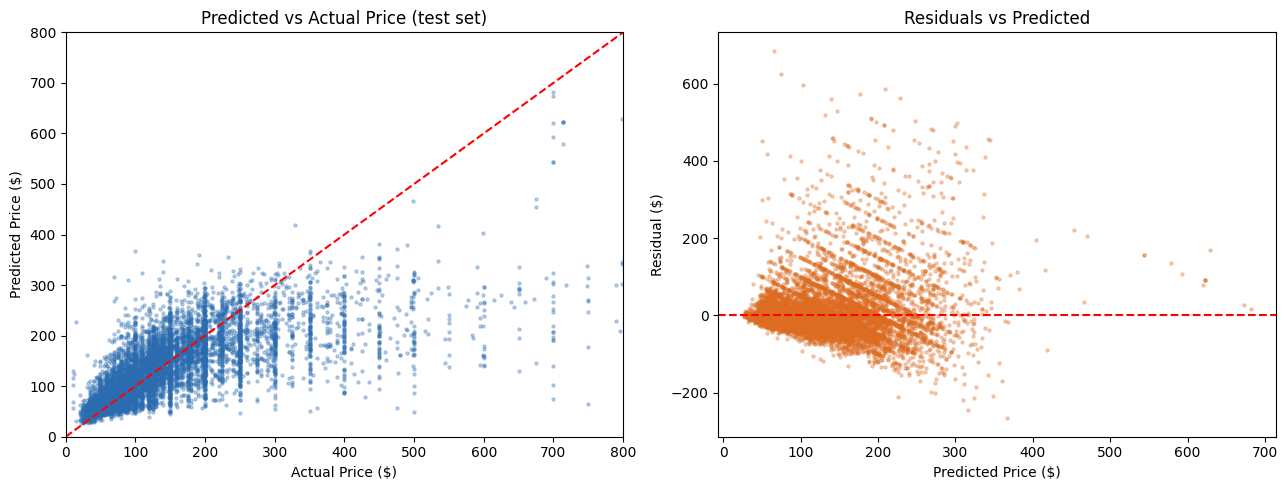

In [16]:
pred_log = hgb_search.best_estimator_.predict(X_test)
pred_d = np.clip(np.expm1(pred_log), 0, None)

fig, axes = plt.subplots(1, 2, figsize=(13,5))
axes[0].scatter(y_test_d, pred_d, s=5, alpha=0.3, color='#2b6cb0')
axes[0].plot([0,800],[0,800], 'r--', lw=1.5)
axes[0].set_xlabel('Actual Price ($)'); axes[0].set_ylabel('Predicted Price ($)')
axes[0].set_title('Predicted vs Actual Price (test set)'); axes[0].set_xlim(0,800); axes[0].set_ylim(0,800)

residuals = y_test_d - pred_d
axes[1].scatter(pred_d, residuals, s=5, alpha=0.3, color='#dd6b20')
axes[1].axhline(0, color='r', linestyle='--')
axes[1].set_xlabel('Predicted Price ($)'); axes[1].set_ylabel('Residual ($)')
axes[1].set_title('Residuals vs Predicted')
plt.tight_layout(); plt.show()

Predictions track the diagonal reasonably well for the bulk of listings (<\$300), with increasing spread at higher prices — expected, since high-end pricing depends on unobserved factors (photos, amenities, host reputation) not present in this dataset.

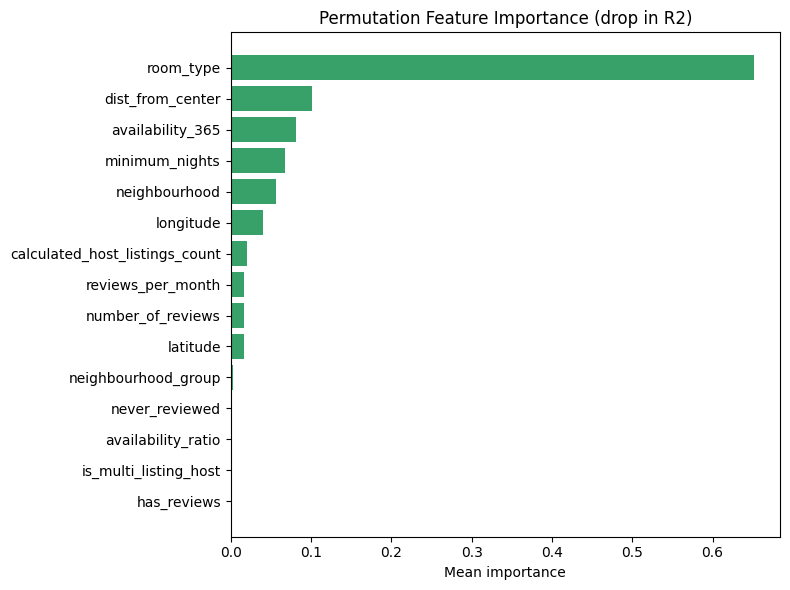

In [17]:
sample_idx = np.random.RandomState(42).choice(len(X_test), size=2000, replace=False)
result = permutation_importance(hgb_search.best_estimator_, X_test.iloc[sample_idx], y_test.iloc[sample_idx],
                                 n_repeats=5, random_state=42, n_jobs=1, scoring='r2')
imp_df = pd.DataFrame({'feature': feature_cols, 'importance': result.importances_mean}).sort_values('importance')

fig, ax = plt.subplots(figsize=(8,6))
ax.barh(imp_df['feature'], imp_df['importance'], color='#38a169')
ax.set_title('Permutation Feature Importance (drop in R2)'); ax.set_xlabel('Mean importance')
plt.tight_layout(); plt.show()

**`room_type` dominates** (0.65 importance) by a wide margin, followed by `dist_from_center`, `availability_365`, `minimum_nights`, and `neighbourhood`. Engineered redundant flags (`has_reviews`, `availability_ratio`, `is_multi_listing_host`) show ~0 importance since HistGB already captures that signal through their continuous counterparts — they were kept for interpretability/app usability rather than dropped, since they didn't hurt performance.

In [18]:
joblib.dump(hgb_search.best_estimator_, 'app/airbnb_price_pipeline.pkl')
joblib.dump({'feature_cols': feature_cols, 'best_model': 'HistGradientBoosting',
             'best_params': hgb_search.best_params_}, 'app/model_meta.pkl')
print("Saved final pipeline -> app/airbnb_price_pipeline.pkl")

Saved final pipeline -> app/airbnb_price_pipeline.pkl

---
## Task 4 — Final Project Summary

**Data & preprocessing:** 48,895 raw listings → 48,410 after removing invalid \$0 prices and capping extreme
outliers (price at ~\$799, minimum_nights at ~45 nights, both 99th percentile). Missingness in
`reviews_per_month`/`last_review` was semantically meaningful (never reviewed) and encoded rather than dropped.
Engineered `dist_from_center`, `availability_ratio`, review/host activity flags, and log-transforms of
skewed counts and the target price itself.

**Modeling:** Compared 5 regressors — Linear Regression, Ridge, RandomForest, GradientBoosting,
HistGradientBoosting. Linear models underfit (R² ≈ 0.60) due to strong non-linear location × room-type
effects. Tree ensembles performed best; **RandomForest overfit** (train R² 0.79 vs test 0.65) even after
tuning, while **HistGradientBoosting generalized best** (train R² 0.70 vs test 0.65, smallest gap) and was
selected as the final model.

**Final performance (test set, HistGradientBoosting):**
- R² (log price) ≈ **0.651**
- MAE ≈ **\$42**
- RMSE ≈ **\$73**

**Key price drivers:** `room_type` (dominant), distance from Manhattan center, availability, minimum nights,
and neighbourhood.

**Application:** A Streamlit app (`app/app.py`) loads the saved pipeline (`airbnb_price_pipeline.pkl`) and
takes listing details (borough, neighbourhood, room type, coordinates, minimum nights, review activity,
availability, host listing count) to return an estimated nightly price.

**Limitations:**
- R² ≈ 0.65 means ~35% of price variance is **unexplained** — this dataset lacks photos, amenities, listing
  quality/description text, seasonality, and real-time demand signals that strongly affect actual Airbnb pricing.
- The model is trained on **2019 NYC data**; absolute dollar predictions will be stale for current pricing and
  won't transfer to other cities without retraining.
- High-price listings (luxury/unique properties) are harder to predict — residual spread increases with price.
- `neighbourhood` target-encoding relies on average historical prices per area; brand-new/rare neighbourhoods
  fall back to the global mean, which can understate very niche premium locations.
